# Basic Tutorial: Your First Energy System Model

This tutorial walks you through a complete, small energy system model with **ETHOS.FINE**, from an empty model to interpreted results. No prior knowledge of FINE is needed, only some basic Python and pandas.

We model the electricity supply of a fictional country with **two regions**, `north` and `south`, over **three investment periods** (2020, 2030 and 2040). The system has to cover a growing electricity demand while the allowed CO<sub>2</sub> emissions shrink from period to period. FINE then decides, at minimal total cost, **what to build where and when**, and **how to operate it hour by hour**.

The model contains one example of every component type FINE offers:

| Component type | In this tutorial | What it does |
|---|---|---|
| **Source** | Wind turbines, PV, natural gas import | brings a commodity into the system |
| **Sink** | Electricity demand, CO<sub>2</sub> to environment | takes a commodity out of the system |
| **Conversion** | Gas power plants | turns commodities into other commodities |
| **Storage** | Batteries | shifts a commodity in time |
| **Transmission** | AC cables | moves a commodity between regions |

Every step below explains only the parameters that are used. The notebooks of the *Modular Examples* go through each component type in depth and list all of its parameters.

After importing the packages, the workflow is always the same, and each step has its own section below:

- Prepare the input data
- Create the `EnergySystemModel`
- Add components
- Optimize
- Look at the results

## 1. Import packages

`fine` is usually imported as `fn`. `pandas` and `numpy` are used to prepare the input data.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # keeps the output of this tutorial readable

import numpy as np
import pandas as pd

import fine as fn

## 2. Prepare the input data

FINE works with plain pandas objects, so input data can come from anywhere: CSV or Excel files, databases, other models. To keep this tutorial self-contained, we create very simple example data instead of reading files. **Time series** are `pd.DataFrame`s with one row per time step (here: the 8760 hours of a year) and one column per region.

We need three time series:

- **PV capacity factors**: how much one unit of installed PV capacity can produce in each hour (between 0 and 1). A value of 0.3 means that 1 GW of PV panels can produce at most 0.3 GW in that hour. We use the same daily profile for every day of the year, a bit higher in the sunny south.
- **Wind capacity factors**, defined the same way. To mimic changing weather, every day gets a random value that applies to all of its 24 hours. The north is windier than the south.
- **Electricity demand** in GW: the same daily profile every day, higher in the south than in the north.

How much capacity may be built at all (the *potential*) is a separate input, `capacityMax`, which we set later when adding the components.

In [2]:
regions = ["north", "south"]

# PV: capacity factor for each hour of a day (0 at night, highest at noon), repeated for all 365 days
pvDailyProfile = [0, 0, 0, 0, 0, 0, 0.02, 0.08, 0.17, 0.27, 0.36, 0.41,
                  0.44, 0.41, 0.36, 0.27, 0.17, 0.08, 0.02, 0, 0, 0, 0, 0]
pvCapacityFactor = pd.DataFrame({
    "north": np.tile(pvDailyProfile, 365) * 0.8,
    "south": np.tile(pvDailyProfile, 365),
})

# Wind: one random capacity factor per day (np.repeat holds it for 24 hours)
np.random.seed(42)  # so that every run produces the same random numbers
windCapacityFactor = pd.DataFrame({
    "north": np.repeat(np.random.uniform(0, 0.8, size=365), 24),
    "south": np.repeat(np.random.uniform(0, 0.5, size=365), 24),
})

# Demand: share of the peak demand for each hour of a day, times the peak demand in GW
demandDailyProfile = [0.6, 0.6, 0.6, 0.6, 0.6, 0.7, 0.9, 1, 1, 1, 1, 1,
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 0.9, 0.8, 0.7]
electricityDemand2020 = pd.DataFrame({
    "north": np.tile(demandDailyProfile, 365) * 20,
    "south": np.tile(demandDailyProfile, 365) * 35,
})

electricityDemand2020.head()

,north,south
0,12.0,21.0
1,12.0,21.0
2,12.0,21.0
3,12.0,21.0
4,12.0,21.0


The capacity factors of the **first week** in one diagram:

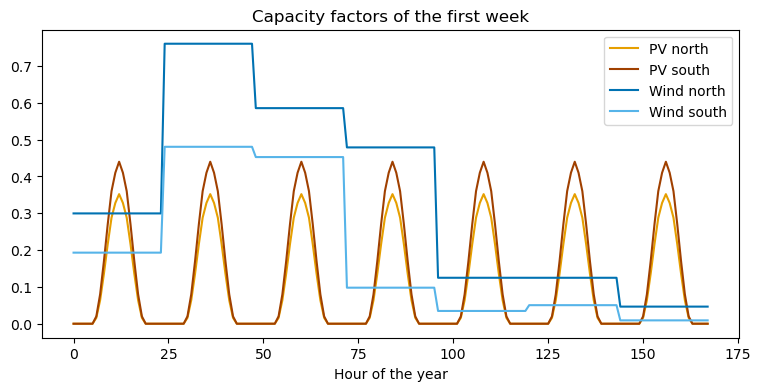

In [3]:
# Colors chosen to stay distinguishable for color-blind readers
ax = pvCapacityFactor[:168].add_prefix("PV ").plot(
    color=["#E69F00", "#A04000"],
    title="Capacity factors of the first week",
    xlabel="Hour of the year",
    figsize=(9, 4),
)
windCapacityFactor[:168].add_prefix("Wind ").plot(ax=ax, color=["#0072B2", "#56B4E9"]);  # same diagram

## 3. Create the energy system model

The `EnergySystemModel` (usually called `esM`) is the container for everything else. It defines the *frame* of the model, which all components added later have to fit into:

- **`locations`**: the regions (nodes) of the model. Every component exists in some or all of them.
- **`commodities`** and **`commodityUnitsDict`**: the energy carriers or materials that flow through the system and the unit in which each of them is measured. FINE does not convert units for you; it is your job to give all inputs of a commodity consistently in this unit. Here, electricity and natural gas are measured in GW and CO<sub>2</sub> in million tonnes per hour.
- **`numberOfTimeSteps`** and **`hoursPerTimeStep`**: the temporal resolution of the operation. We model every hour of a year.
- **`numberOfInvestmentPeriods`**, **`investmentPeriodInterval`** and **`startYear`**: the *investment periods* in which FINE may build new capacity. With three periods, an interval of 10 years and a start year of 2020, these are 2020, 2030 and 2040. Each of them is represented by one full year of operation, and capacity built in one period remains available in later periods until it reaches the end of its lifetime.
- **`costUnit`** and **`lengthUnit`**: the units of all cost and length (distance) inputs.

### A CO<sub>2</sub> limit per investment period

To make the investment periods differ, we cap the CO<sub>2</sub> emissions of the whole system: 70 million tonnes in 2020, 35 in 2030 and 10 in 2040. For comparison: covering the whole electricity demand of 2020 with gas power plants alone would emit about 140 million tonnes. Limits like this are defined with **`balanceLimit`**: each row is a limit with an ID (here `"CO2 limit"`), the column `"Total"` holds the value for the whole system (a column per region would hold regional limits instead), and components later join the limit by referring to its ID.

Two conventions are important here:

- Commodity flows that **leave** the system (into a `Sink`) count as **negative** in a balance limit.
- `lowerBound=True` means the balance must be **greater than or equal** to the value.

So a value of `-70` with `lowerBound=True` reads as *"at most 70 million tonnes of CO<sub>2</sub> may leave the system"*. Many FINE parameters accept a dictionary with the investment periods (as calendar years) as keys if their value should differ between periods, and `balanceLimit` is one of them.

In [4]:
investmentPeriods = [2020, 2030, 2040]
co2LimitPerPeriod = {2020: 70, 2030: 35, 2040: 10}  # million tonnes of CO2 per year

balanceLimit = {
    year: pd.DataFrame(
        index=["CO2 limit"],
        columns=["Total", "lowerBound"],
        data=[[-limit, True]],
    )
    for year, limit in co2LimitPerPeriod.items()
}

esM = fn.EnergySystemModel(
    locations=set(regions),
    commodities={"electricity", "naturalGas", "CO2"},
    commodityUnitsDict={
        "electricity": "GW_el",
        "naturalGas": "GW_CH4",
        "CO2": "Mt_CO2/h",
    },
    numberOfTimeSteps=8760,
    hoursPerTimeStep=1,
    numberOfInvestmentPeriods=3,
    investmentPeriodInterval=10,
    startYear=2020,
    costUnit="1e6 Euro",
    lengthUnit="km",
    balanceLimit=balanceLimit,
    verboseLogLevel=1,  # only print warnings
)

## 4. Add components

The model is still empty. In the following subsections we add components with `esM.add(...)`, one subsection per component type. Every component needs at least a reference to the model (`esM=esM`), a unique `name` and the commodity or commodities it handles. All other parameters have sensible defaults.

Most components below use the same handful of parameters, so here they are once:

- **`hasCapacityVariable`**: if `True`, FINE optimizes the *size* (capacity) of the component in every region and investment period. If `False`, the component has no capacity, only an operation (useful for fuel imports or fixed demands).
- **`capacityMax`**: an upper limit for the capacity, e.g. the available land for wind turbines. Given as a single number (same for all regions) or a `pd.Series` per region.
- **`investPerCapacity`** and **`opexPerCapacity`**: investment cost and yearly fixed operation cost per unit of capacity, in `costUnit` per capacity unit (here: million Euro per GW).
- **`interestRate`** and **`economicLifetime`**: used to spread the investment into yearly payments (annuities).
- **`technicalLifetime`**: how long the capacity physically exists before it is decommissioned. Defaults to the economic lifetime.

Cost parameters can be given as a dictionary keyed by investment period. We use this to let renewables and batteries become cheaper over time.

### Sources

A **`Source`** brings a commodity into the system. Its operation in every hour is a decision of the optimization, limited by its capacity.

**Wind turbines and PV** have a capacity variable. The parameter **`operationRateMax`** limits their hourly production to *capacity factor × installed capacity*, which is exactly what our capacity-factor time series describe. Wherever and whenever the wind does not blow, the turbines cannot produce, however many are built.

In [5]:
esM.add(
    fn.Source(
        esM=esM,
        name="Wind turbines",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=windCapacityFactor,
        capacityMax=pd.Series({"north": 150, "south": 80}),  # GW
        investPerCapacity={2020: 1300, 2030: 1150, 2040: 1050},  # million Euro per GW
        opexPerCapacity=30,  # million Euro per GW and year
        interestRate=0.08,
        economicLifetime=20,
    )
)

esM.add(
    fn.Source(
        esM=esM,
        name="PV",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=pvCapacityFactor,
        capacityMax=pd.Series({"north": 80, "south": 150}),
        investPerCapacity={2020: 750, 2030: 500, 2040: 380},
        opexPerCapacity=12,
        interestRate=0.08,
        economicLifetime=25,
    )
)

**Natural gas** is simply bought at a price. It has no capacity variable, so FINE can import any amount in any hour, and every unit costs **`commodityCost`** (here: million Euro per GWh, i.e. 25 to 35 Euro per MWh, rising over time).

In [6]:
esM.add(
    fn.Source(
        esM=esM,
        name="Natural gas import",
        commodity="naturalGas",
        hasCapacityVariable=False,
        commodityCost={2020: 0.025, 2030: 0.03, 2040: 0.035},
    )
)

### Conversions

A **`Conversion`** turns one or more commodities into one or more others. Its capacity is measured in the **`physicalUnit`**, and **`commodityConversionFactors`** state how much of every commodity is produced (positive) or consumed (negative) per unit of operation.

Our gas power plants have an efficiency of 60 %. Producing 1 GWh of electricity therefore consumes 1/0.6 GWh of natural gas and, at 201 t CO<sub>2</sub> per GWh of gas, emits 201/0.6 t (= 201·10<sup>-6</sup>/0.6 million tonnes) of CO<sub>2</sub>.

In [7]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="Gas power plants",
        physicalUnit="GW_el",
        commodityConversionFactors={
            "electricity": 1,
            "naturalGas": -1 / 0.6,
            "CO2": 201e-6 / 0.6,
        },
        hasCapacityVariable=True,
        investPerCapacity=650,
        opexPerCapacity=20,
        interestRate=0.08,
        economicLifetime=30,
    )
)

### Storages

A **`Storage`** shifts a commodity from one hour to a later one. Its capacity is the amount it can hold (here GWh). The most important technical parameters are

- **`chargeEfficiency`** and **`dischargeEfficiency`**: losses when charging and discharging,
- **`selfDischarge`**: the share of the content lost per hour (here: 3 % per month, converted to an hourly value),
- **`chargeRate`** and **`dischargeRate`**: how much of the capacity can be charged or discharged within one hour. A rate of 1 means the battery can be fully charged or emptied in one hour.

In [8]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        investPerCapacity={2020: 300, 2030: 180, 2040: 120},  # million Euro per GWh
        opexPerCapacity=3,
        interestRate=0.08,
        economicLifetime=10,
    )
)

### Transmissions

A **`Transmission`** moves a commodity between regions. Its inputs refer to *pairs* of regions, so they are given as square `pd.DataFrame`s with regions as both index and columns.

- **`distances`**: the length of each connection in `lengthUnit`.
- **`losses`**: the share of the transported electricity lost per km (0.01 % per km, i.e. 4 % over 400 km).
- **`investPerCapacity`** and **`opexPerCapacity`** are given *per capacity and per km*, so longer connections are more expensive.

A capacity is optimized for each connection; the north and the south may want to exchange wind and solar power.

In [9]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="AC cables",
        commodity="electricity",
        hasCapacityVariable=True,
        distances=pd.DataFrame([[0, 400], [400, 0]], index=regions, columns=regions),
        losses=0.0001,
        investPerCapacity=1.5,  # million Euro per GW and km
        opexPerCapacity=0.015,
        interestRate=0.08,
        economicLifetime=40,
    )
)

### Sinks

A **`Sink`** takes a commodity out of the system.

The **electricity demand** must be met exactly in every hour, so it is given as **`operationRateFix`**: a fixed hourly operation instead of an upper limit. The demand grows by 15 % per decade. Time series can, just like costs, be given as a dictionary with one `DataFrame` per investment period.

In [10]:
electricityDemand = {
    2020: electricityDemand2020,
    2030: electricityDemand2020 * 1.15,
    2040: electricityDemand2020 * 1.15**2,
}

esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=electricityDemand,
    )
)

The **CO<sub>2</sub> emitted by the gas power plants** also has to go somewhere, otherwise the CO<sub>2</sub> balance of each region could not be closed and the plants could not run at all. This sink has no limit of its own, but with **`balanceLimitID="CO2 limit"`** it joins the CO<sub>2</sub> limit defined in section 3, so its total yearly operation (the emissions) is capped per investment period.

In [11]:
esM.add(
    fn.Sink(
        esM=esM,
        name="CO2 to environment",
        commodity="CO2",
        hasCapacityVariable=False,
        balanceLimitID="CO2 limit",
    )
)

## 5. Optimize

The model is complete. Before solving it, we reduce its size with **time series aggregation**: instead of all 365 days of a year, the model only operates **8 typical days**, which are clustered from the original time series and weighted by how often they occur. This makes the optimization much faster at the cost of some accuracy (e.g. long calm periods are smoothed out). For real studies you would check how many typical days are needed; for learning, 8 are enough.

Then `esM.optimize` builds the optimization problem and hands it to a solver. FINE minimizes the total discounted cost of investment and operation across all investment periods. `STANDARD_SOLVER` uses the commercial solver Gurobi if a full license is available and the free open-source solver [HiGHS](https://highs.dev/) otherwise. Both are installed together with FINE; you can also choose one directly, e.g. `solver="highs"`. When you run the notebook, the solver prints a log while it works; its last lines report that an optimal solution was found. (The log is hidden on the documentation website.)

In [12]:
esM.aggregateTemporally(numberOfTypicalPeriods=8)

In [13]:
esM.optimize(
    timeSeriesAggregation=True,
    solver=fn.utils.ImplementedSolvers.STANDARD_SOLVER.value,
)

Set parameter OutputFlag to value 1


Set parameter Threads to value 3


Set parameter LogFile to value ""


Set parameter QCPDual to value 1


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))


...

Solved with dual simplex


Iteration    Objective       Primal Inf.    Dual Inf.      Time


    5491    3.6282658e+05   0.000000e+00   0.000000e+00      1s


Solved in 5491 iterations and 0.81 seconds (1.51 work units)


Optimal objective  3.628265780e+05


## 6. Look at the results

### Optimization summaries

The main entry point to the results is **`esM.getOptimizationSummary`**. It returns a table per *modeling class* (all sources and sinks together, all conversions, all storages, all transmissions) and per investment period. The rows are component, property and unit; the columns are the regions. `outputLevel=2` hides components that were not used.

Here are the sources and sinks in 2040:

In [14]:
esM.getOptimizationSummary("SourceSinkModel", outputLevel=2, ip=2040)

north  \
Component          Property                        Unit                            
CO2 to environment operation                       [Mt_CO2/h*h]         2.983184   
                   operation_annual                [Mt_CO2/h*h/a]       2.983184   
Electricity demand operation                       [GW_el*h]           202739.25   
                   operation_annual                [GW_el*h/a]         202739.25   
Natural gas import NPVcontribution                 [1e6 Euro]         807.659774   
                   TAC                             [1e6 Euro/a]        519.45989   
                   commodCosts                     [1e6 Euro/a]        519.45989   
                   operation                       [GW_CH4*h]       14841.711134   
                   operation_annual                [GW_CH4*h/a]     14841.711134   
PV                 NPVcontribution                 [1e6 Euro]         5920.44761   
                   TAC                             [1e6 Euro/a]      3807.834883   
                   capacity                        [GW_el]                  80.0   
                   capexCap                        [1e6 Euro/a]      2847.834883   
                   commissioning                   [GW_el]                  80.0   
                   decommissioning                 [GW_el]                   0.0   
                   invest                          [1e6 Euro]            30400.0   
                   operation                       [GW_el*h]        57690.200555   
                   operation_annual                [GW_el*h/a]      57690.200555   
                   opexCap                         [1e6 Euro/a]            960.0   
                   revenueLifetimeShorteningResale [1e6 Euro]             6080.0   
Wind turbines      NPVcontribution                 [1e6 Euro]        19541.35126   
                   TAC                             [1e6 Euro/a]     12568.346838   
                   capacity                        [GW_el]             90.653186   
                   capexCap                        [1e6 Euro/a]      9848.751256   
                   commissioning                   [GW_el]             75.546723   
                   decommissioning                 [GW_el]             57.608885   
                   invest                          [1e6 Euro]        79324.05951   
                   operation                       [GW_el*h]       194217.556546   
                   operation_annual                [GW_el*h/a]     194217.556546   
                   opexCap                         [1e6 Euro/a]      2719.595581   

                                                                           south  
Component          Property                        Unit                           
CO2 to environment operation                       [Mt_CO2/h*h]         7.016816  
                   operation_annual                [Mt_CO2/h*h/a]       7.016816  
Electricity demand operation                       [GW_el*h]         354793.6875  
                   operation_annual                [GW_el*h/a]       354793.6875  
Natural gas import NPVcontribution                 [1e6 Euro]        1899.715269  
                   TAC                             [1e6 Euro/a]      1221.833643  
                   commodCosts                     [1e6 Euro/a]      1221.833643  
                   operation                       [GW_CH4*h]       34909.532647  
                   operation_annual                [GW_CH4*h/a]     34909.532647  
PV                 NPVcontribution                 [1e6 Euro]       12275.646183  
                   TAC                             [1e6 Euro/a]      7895.287119  
                   capacity                        [GW_el]                 150.0  
                   capexCap                        [1e6 Euro/a]      6095.287119  
                   commissioning                   [GW_el]             82.784785  
                   decommissioning                 [GW_el]

The most important properties are

- `capacity`: the installed capacity in that period (everything still in operation, not only what was newly built),
- `commissioning`: the capacity newly built in that period,
- `operation`: the yearly sum of the hourly operation, e.g. the yearly electricity production in GWh,
- `TAC`: the total annual cost of the component in that period (`capexCap`, `opexCap`, `opexOp`, `commodCosts`, ... break it down).

### How the system develops over time

To compare the investment periods, we collect the installed **capacity** and the yearly electricity **generation** (the property `operation`) of the power generators from the summaries of every period, add up both regions and plot them as bar charts. (The batteries are left out: they only shift electricity in time, and their capacity is measured in GWh instead of GW.)

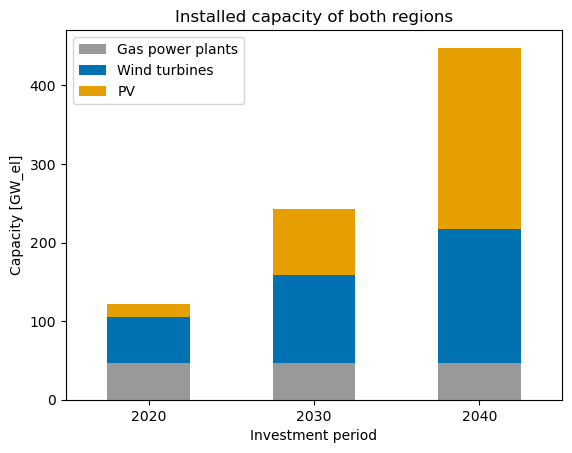

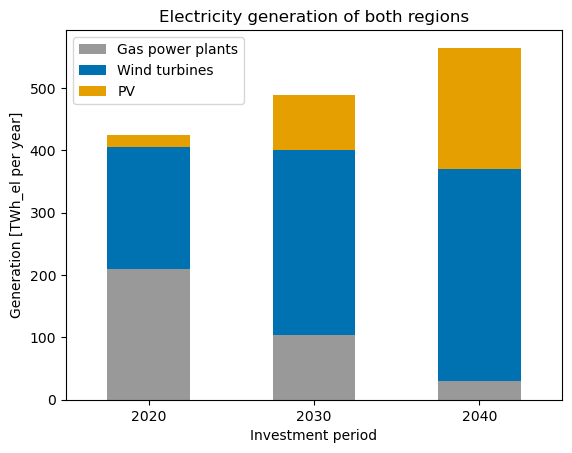

In [15]:
generators = ["Gas power plants", "Wind turbines", "PV"]
colors = ["#999999", "#0072B2", "#E69F00"]  # distinguishable for color-blind readers
capacity = pd.DataFrame(columns=generators)
generation = pd.DataFrame(columns=generators)

for year in investmentPeriods:
    for modelingClass in ["SourceSinkModel", "ConversionModel"]:
        summary = esM.getOptimizationSummary(modelingClass, outputLevel=1, ip=year)
        capacities = summary.xs("capacity", level="Property").droplevel("Unit")
        operations = summary.xs("operation", level="Property").droplevel("Unit")
        for component in capacities.index:
            capacity.loc[year, component] = capacities.loc[component].sum()  # both regions
            generation.loc[year, component] = operations.loc[component].sum() / 1000  # GWh -> TWh

capacity.plot.bar(stacked=True, color=colors, rot=0, xlabel="Investment period",
                  ylabel="Capacity [GW_el]", title="Installed capacity of both regions")
generation.plot.bar(stacked=True, color=colors, rot=0, xlabel="Investment period",
                    ylabel="Generation [TWh_el per year]", title="Electricity generation of both regions");

The CO<sub>2</sub> limit drives the transformation:

- **2020:** gas power plants still produce about half of the electricity. The other half already comes from wind turbines in the windy north and some PV in the sunny south. The AC cables are built right away to bring the northern wind power to the south, where the demand is higher.
- **2030:** the CO<sub>2</sub> limit is halved and renewables become cheaper, so wind turbines (now also in the south) and PV grow strongly.
- **2040:** all wind and PV potentials are used, including PV in the less sunny north.

The two charts tell different stories about the gas power plants: their **capacity** stays the same, because plants built in 2020 have a lifetime of 30 years and still exist in 2040. Their **generation**, however, drops from about 210 TWh in 2020 to about 30 TWh in 2040. In the end they mainly serve as backup for hours with little wind and sun (see their operation below).

### Looking at the operation

FINE also provides plotting functions for single components. `fn.plotOperationColorMap` shows the hourly operation of a component in one region as a heat map, with the days of the year on the x-axis and the hours of the day on the y-axis. Since we optimized with 8 typical days, each year is assembled from those 8 days.

Here is when the batteries in the south are charged in 2040: mainly around midday, with surplus PV power. The stored electricity is used later, when the sun is down.

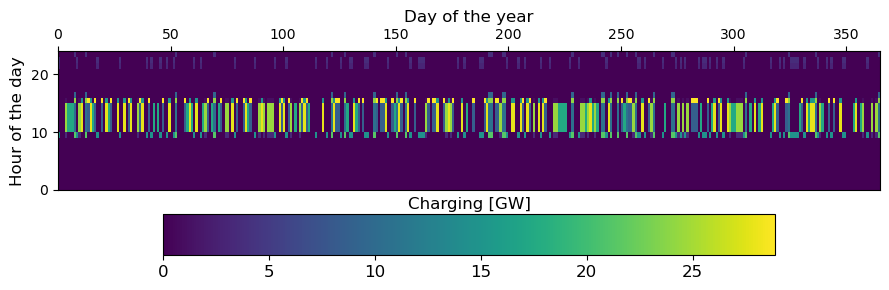

In [16]:
fn.plotOperationColorMap(
    esM,
    "Batteries",
    "south",
    variableName="chargeOperationVariablesOptimum",  # plot the charging (not the discharging)
    ip=2040,
    figsize=(9, 3),
    xlabel="Day of the year",
    ylabel="Hour of the day",
    zlabel="Charging [GW]",
);

And the electricity production of the gas power plants in the south in 2040: they never run around midday, when PV produces, and only on some days in the evening and at night, when the wind is weak.

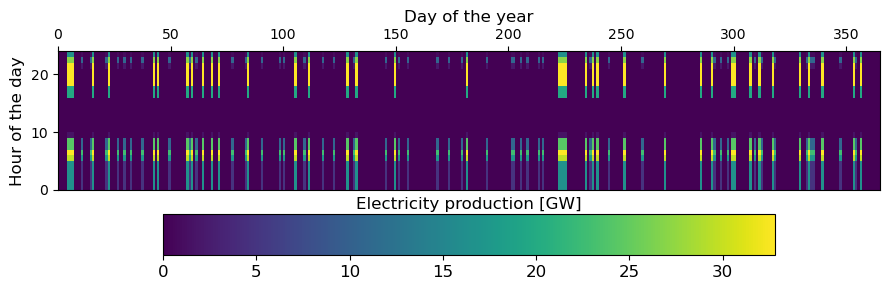

In [17]:
fn.plotOperationColorMap(
    esM,
    "Gas power plants",
    "south",
    ip=2040,
    figsize=(9, 3),
    xlabel="Day of the year",
    ylabel="Hour of the day",
    zlabel="Electricity production [GW]",
);

## Where to go from here

You have now built, optimized and analyzed a complete energy system model with FINE. To go further:

- The **Modular Examples** explain the `EnergySystemModel` and every component type in depth, including all of their parameters.
- The **User Guide** contains the mathematical description of every component.
- The other **Examples** show larger models and advanced features such as spatial aggregation, stochastic optimization or saving models to NetCDF files.

Some things to try with this model:

- Lower the CO<sub>2</sub> limit for 2040 to 0. What has to change in the system?
- Remove the AC cables. How do the capacities in each region change?
- Increase the number of typical days in `aggregateTemporally` and compare the results.